In [57]:
import os
import random
from PIL import Image
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from typing import List, Tuple

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
root = "tiny-imagenet-200"

Классификация: Tiny ImageNet-200

In [50]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2


class TinyImageNetDataset(Dataset):
    def __init__(self, split, root="./tiny-imagenet-200", transform=None, num_classes=10, augmentation=None):
        super().__init__()
        self.root = root
        self.split = split
        self.transform = transform 
        self.augmentation = augmentation  # аугментация добавляется в конструктор
        self.classes = None

        wnids_path = self.root + "/wnids.txt"
        with open(wnids_path, mode='r', encoding='utf-8') as file:
            file = file.readlines()
            if num_classes:
                file = file[:num_classes]
            self.classes = {cls.strip(): i for i, cls in enumerate(file)}

        match split:
            case 'train':
                self._select_train_frames()
            case 'val':
                self._select_val_frames()
            case 'test':
                self._select_test_frames()
                
    def _select_train_frames(self, train_root: str = "train") -> list:
        train_root = self.root + "/" + train_root
        samples = []
        for cls_name, cls_label in self.classes.items():
            cls_images_root = train_root + f'/{cls_name}' + '/images'
            cls_images_paths = os.listdir(cls_images_root)
            cls_images_paths = list(map(lambda x: cls_images_root + '/' + str(x), cls_images_paths))
            labels = [cls_label] * len(cls_images_paths)
            samples.extend(list(zip(cls_images_paths, labels)))
        self.samples = samples
    
    def _select_val_frames(self, val_root: str = "val", 
                           annotations_path: str = "val/val_annotations.txt") -> list:
        val_root = self.root + "/" + val_root
        annotations_path = self.root + "/" + annotations_path
        images_path = val_root + '/images/'
        with open(annotations_path, mode='r', encoding='utf-8') as file:
            lines = file.readlines()
        self.samples = []
        for line in lines:
            parts = line.strip().split('\t')
            
            img_name = parts[0]
            cls_name = parts[1]
            
            if cls_name in self.classes:
                full_path = os.path.join(images_path, img_name)
                label = self.classes[cls_name]
                self.samples.append((full_path, label))       
            
    def _select_test_frames(self, test_root: str = "test/images/") -> list:
        test_root = self.root + "/" + test_root
        images = os.listdir(test_root)
        images = list(map(lambda x: test_root + str(x), images))
        labels = [-1]*len(images)
        self.samples = list(zip(images, labels))

    def __len__(self):
        return len(self.samples)
    
    def _load_image(self, img_path: str):
        with open(img_path, mode='rb') as file:
            image = Image.open(file)
            return image.convert(mode='RGB')
    
    def __getitem__(self, index):
        image_path, image_label = self.samples[index]

        image = self._load_image(image_path)
        
        # Применяем аугментацию только для тренировочного датасета
        if self.augmentation:
            image = np.array(image)  # Преобразуем изображение в numpy массив перед аугментацией
            sample = self.augmentation(image=image)  # Применяем аугментацию
            image = sample['image']  # Извлекаем изображение после аугментации

        # Применяем нормализацию или другие трансформации
        if self.transform:
            image = self.transform(image)

        # Преобразуем изображение в float32, если это необходимо
        image = image.float()

        # # Отладочные выводы
        # print(f"Image shape after transformations: {image.shape}")
        # print(f"Image dtype after transformations: {image.dtype}")
        # print(f"Label: {image_label}")
        
        return image, image_label


# Определяем аугментации с использованием albumentations
train_augmentation = A.Compose([
    A.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0), p=1.0),  # Случайное кадрирование
    A.HorizontalFlip(p=0.5),  # Случайный горизонтальный флип
    A.RandomBrightnessContrast(p=0.2),  # Случайное изменение яркости и контраста
    A.Rotate(limit=15, p=0.5),  # Случайное вращение
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),  # Увеличение контраста с помощью CLAHE
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3),  # Изменение оттенка, насыщенности и яркости
    ToTensorV2(),  # Преобразуем в тензор для PyTorch
])

val_augmentation = A.Compose([
    A.Resize(64, 64),  # Преобразуем все изображения в 64x64
    ToTensorV2(),  # Преобразуем в тензор для PyTorch
])

# Датасеты
train_dataset = TinyImageNetDataset(split='train', transform=None, augmentation=train_augmentation)
val_dataset = TinyImageNetDataset(split='val', transform=None, augmentation=val_augmentation)
test_dataset = TinyImageNetDataset(split='test', transform=None, augmentation=val_augmentation)

# Даталоадеры
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

# Вывод статистики
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Классов: {len(train_dataset.classes)}")



Train size: 5000
Val size: 500
Классов: 10


In [21]:
def print_cls_names(root_dir):
    print("Выбранные классы:")
    with open(os.path.join(root_dir, 'words.txt'), 'r') as f:
        words_strings = [line.strip() for line in f]
        for cls in train_dataset.classes:
            for line in words_strings:
                if line.startswith(cls):
                    print(f"{cls}: {line}")
                    break
print_cls_names(root)

Выбранные классы:
n02124075: n02124075	Egyptian cat
n04067472: n04067472	reel
n04540053: n04540053	volleyball
n04099969: n04099969	rocking chair, rocker
n07749582: n07749582	lemon
n01641577: n01641577	bullfrog, Rana catesbeiana
n02802426: n02802426	basketball
n09246464: n09246464	cliff, drop, drop-off
n07920052: n07920052	espresso
n03970156: n03970156	plunger, plumber's helper


In [52]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=200):
        super(SimpleCNN, self).__init__()
        
        # Свёрточные слои
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)  # Даунсэмплинг
        
        # Правильная размерность для входа в полносвязанный слой
        self.fc1 = nn.Linear(256 * 8 * 8, 512)  # 8x8 после 3 max-pooling
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # Conv + BN + ReLU
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        
        x = x.view(-1, 256 * 8 * 8)  # Преобразуем для полносвязного слоя
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # Выходной слой для классов
        
        return x


Training Progress:   5%| | 1/20 [00:06<02:12,  6.99s/it, Train Loss=2.76, Train Acc=27.8, Val Acc=38

Best model saved at epoch 1


Training Progress:  10%| | 2/20 [00:13<02:03,  6.87s/it, Train Loss=1.76, Train Acc=38.1, Val Acc=41

Best model saved at epoch 2


Training Progress:  15%|▏| 3/20 [00:20<01:56,  6.85s/it, Train Loss=1.63, Train Acc=43.1, Val Acc=49

...

Best model saved at epoch 18


Training Progress:  95%|▉| 19/20 [02:08<00:06,  6.79s/it, Train Loss=0.97, Train Acc=66.5, Val Acc=5

Best model saved at epoch 19


Training Progress: 100%|█| 20/20 [02:15<00:00,  6.79s/it, Train Loss=0.942, Train Acc=68, Val Acc=60

Best model saved at epoch 20


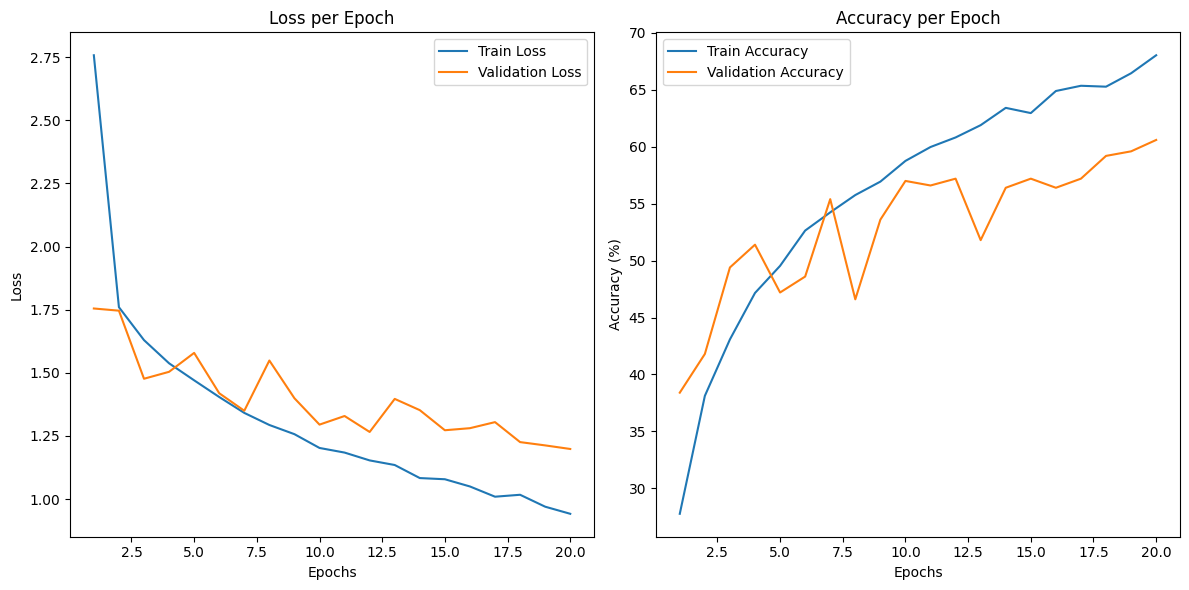

In [53]:
import torch
import torch.optim as optim
from torch import nn
import matplotlib.pyplot as plt
from tqdm import tqdm

# Функция для обучения модели с обработкой ошибок
def train_model(model, train_loader, val_loader, num_epochs=10):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_accuracy = 0
    
    # Создаем статус-бар для всех эпох
    with tqdm(total=num_epochs, desc="Training Progress", ncols=100) as pbar:
        for epoch in range(num_epochs):
            model.train()
            train_loss = 0
            correct_preds = 0
            total_preds = 0

            try:
                # Обучение
                for images, labels in train_loader:
                    
                    assert images.size(0) == labels.size(0), "Mismatch between batch size of images and labels"
                    
                    images, labels = images.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()
                    
                    train_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    correct_preds += (predicted == labels).sum().item()
                    total_preds += labels.size(0)  # Размер батча
                
            except Exception as e:
                print(f"Error during training epoch {epoch+1}: {e}")
                break

            # Средняя ошибка на обучении
            train_accuracy = 100 * correct_preds / total_preds
            train_losses.append(train_loss / len(train_loader))  # Обновление потерь
            train_accuracies.append(train_accuracy)

            # Оценка на валидации
            model.eval()
            correct_preds = 0
            total_preds = 0
            val_loss = 0

            try:
                with torch.no_grad():  # Отключаем градиенты для валидации
                    for images, labels in val_loader:
                        assert images.size(0) == labels.size(0), "Mismatch between batch size of images and labels"
                        
                        images, labels = images.to(device), labels.to(device)
                        
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()
                        
                        _, predicted = torch.max(outputs, 1)
                        correct_preds += (predicted == labels).sum().item()
                        total_preds += labels.size(0)  # Размер батча
            except Exception as e:
                print(f"Error during validation epoch {epoch+1}: {e}")
                break

            # Средняя ошибка на валидации
            val_accuracy = 100 * correct_preds / total_preds
            val_losses.append(val_loss / len(val_loader))
            val_accuracies.append(val_accuracy)

            # Сохраняем модель, если она показала лучший результат на валидации
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                try:
                    torch.save(model.state_dict(), 'best_model_hw3.pth')
                    print(f"Best model saved at epoch {epoch+1}")
                except Exception as e:
                    print(f"Error saving model at epoch {epoch+1}: {e}")

            # Обновляем статус-бар
            pbar.set_postfix({
                'Train Loss': train_loss / len(train_loader), 
                'Train Acc': train_accuracy, 
                'Val Acc': val_accuracy
            })
            pbar.update(1)

    # Отображаем графики
    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

# Функция для отображения графиков
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    # График потерь
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # График точности
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Переносим модель на GPU, если оно доступно
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Создаем модель
model = SimpleCNN(num_classes=10)  # Убедитесь, что количество классов соответствует
model.to(device)

# Определяем оптимизатор и функцию потерь
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Запуск обучения с добавлением обработки ошибок
try:
    train_model(model, train_loader, val_loader, num_epochs=20)
except Exception as e:
    print(f"Training failed: {e}")


# Создание кастомного MOONDATASET

>### Требования к архитектуре U-Net:
>- Глубина: 4 уровня down/4 up (энкодер-декодер с skip-связями).
>- Базовые каналы на первом уровне: 32 или 64 (по желанию можно выбрать свое количество каналов, но надо будет объяснить).
>- Даунсемплинг: stride 2 или MaxPool.
>- Итоговый слой: 1 канал с сигмоидой (бинарная сегментация).
>- Ограничение на количество параметров: до ~2.5M (рекомендуется укладываться, но допускается ±10%).
>- Вход: 128×128×3.

In [58]:
class MoonSegmentationDataset(Dataset):

    def __init__(self, root_dir, image_folder='render', mask_folder='ground', 
                 image_ids=None, augmentation=None, preprocessing=None):
        self.root_dir = root_dir
        self.image_folder = image_folder
        self.mask_folder = mask_folder
        self.augmentation = augmentation
        self.preprocessing = preprocessing
        
        images_dir = os.path.join(root_dir, 'images', image_folder)
        masks_dir = os.path.join(root_dir, 'images', mask_folder)
        
        if image_ids is None:
            all_images = os.listdir(images_dir)
            self.image_ids = [img.replace('.png', '') for img in all_images if img.endswith('.png')]
        else:
            self.image_ids = image_ids
        
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        
        image_path = os.path.join(self.root_dir, 'images', self.image_folder, f"{image_id}.png")
        
        # Для масок убираем префикс "render" если он есть
        # Например: render0001 - 0001
        mask_id = image_id.replace('render', '') if 'render' in image_id else image_id
        mask_path = os.path.join(self.root_dir, 'images', self.mask_folder, f"ground{mask_id}.png")
        
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Так как используем opencv, то не забываем преводить из BGR в RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Нормализуем бинарную маску к [0, 1]
        # 0 = фон, 1 = камни
        mask = (mask > 0).astype(np.float32)
        
        # Применяем аугментации
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # Применяем предобработку
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        return image, mask


Аугментрование

In [59]:
# Аугментации для обучения
train_augmentation = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0)),
        A.GaussianBlur(blur_limit=(3, 7)),
        A.MedianBlur(blur_limit=5),
    ], p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])

preprocessing = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_augmentation = A.Compose([
    A.Resize(256, 256),
])

C:\Users\Stasy\AppData\Local\Temp\ipykernel_20048\2297332127.py:9: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),


Разделение на train/val

In [60]:
# Путь к данным
DATA_ROOT = "MOON_SEGMENTATION_BINARY/"

images_dir = os.path.join(DATA_ROOT, 'images', 'render')
all_images = [img.replace('.png', '') for img in os.listdir(images_dir) if img.endswith('.png')][:100]

print(f"Всего изображений: {len(all_images)}")

train_ids, val_ids = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Train: {len(train_ids)} изображений")
print(f"Val: {len(val_ids)} изображений")

train_dataset = MoonSegmentationDataset(
    root_dir=DATA_ROOT,
    image_folder='render',
    mask_folder='ground',
    image_ids=train_ids,
    augmentation=train_augmentation,
    preprocessing=preprocessing
)

val_dataset = MoonSegmentationDataset(
    root_dir=DATA_ROOT,
    image_folder='render',
    mask_folder='ground',
    image_ids=val_ids,
    augmentation=val_augmentation,
    preprocessing=preprocessing
)

BATCH_SIZE = 4
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Батчей в train: {len(train_loader)}")
print(f"Батчей в val: {len(val_loader)}")


Всего изображений: 100
Train: 80 изображений
Val: 20 изображений
Батчей в train: 20
Батчей в val: 5


Размер батча изображений: torch.Size([4, 3, 256, 256])
Размер батча масок: torch.Size([4, 256, 256])


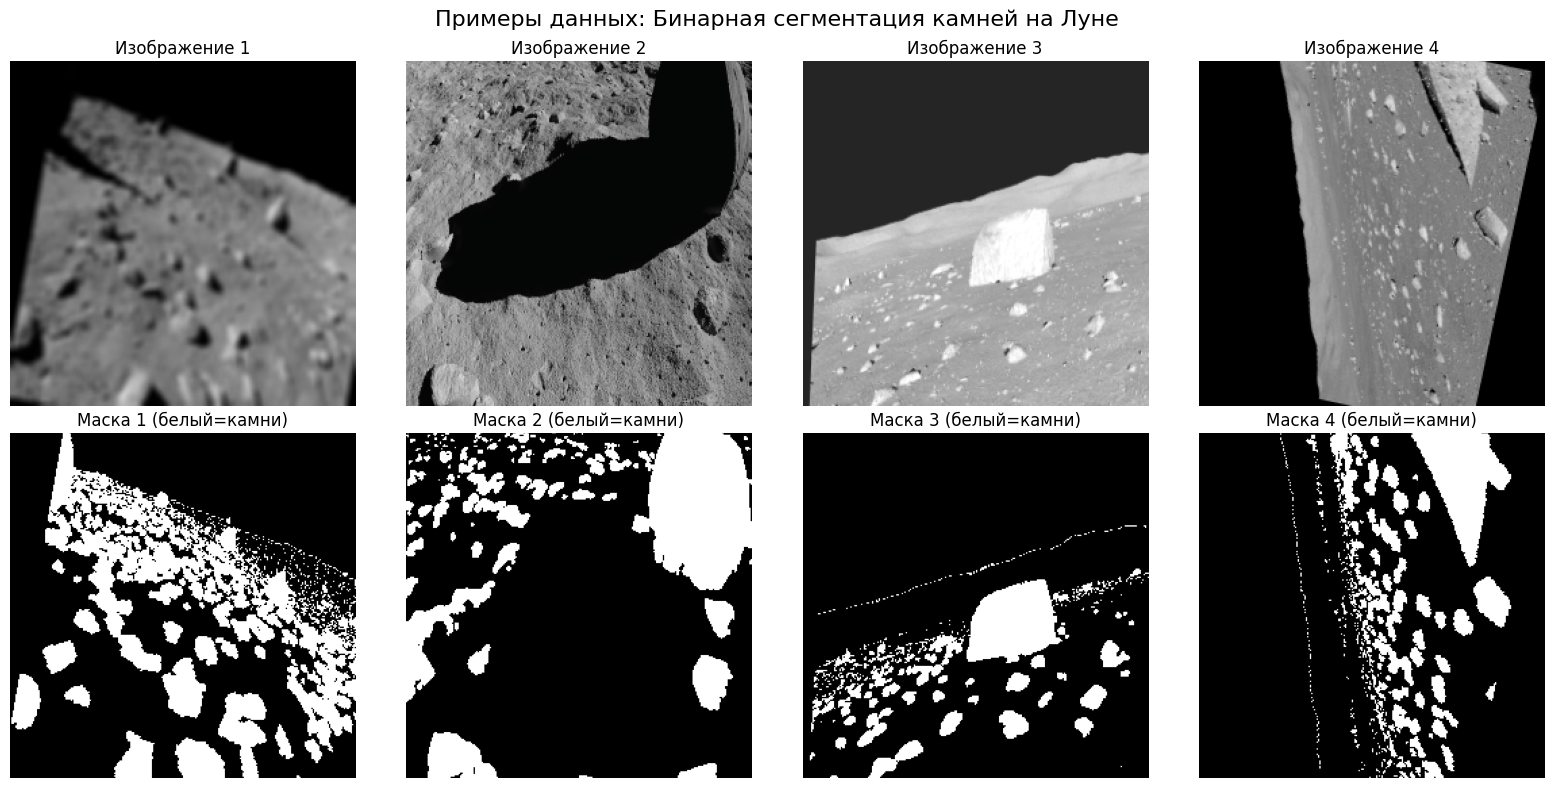

In [61]:
def denormalize(img_tensor):
    """Денормализация изображения для визуализации"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1)

images, masks = next(iter(train_loader))

print(f"Размер батча изображений: {images.shape}")
print(f"Размер батча масок: {masks.shape}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(min(4, len(images))):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    mask = masks[i].numpy()
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Изображение {i+1}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f"Маска {i+1} (белый=камни)")
    axes[1, i].axis('off')

plt.suptitle("Примеры данных: Бинарная сегментация камней на Луне", fontsize=16)
plt.tight_layout()
plt.show()


## Полная кастомная U-Net архитектура

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=64):
        super(UNet, self).__init__()

        self.encoder1 = self.conv_block(in_channels, base_channels)
        self.encoder2 = self.conv_block(base_channels, base_channels * 2)
        self.encoder3 = self.conv_block(base_channels * 2, base_channels * 4)
        self.encoder4 = self.conv_block(base_channels * 4, base_channels * 8)

        self.pool = nn.MaxPool2d(2, 2)

        self.decoder4 = self.conv_block(base_channels * 8, base_channels * 4)
        self.decoder3 = self.conv_block(base_channels * 4, base_channels * 2)
        self.decoder2 = self.conv_block(base_channels * 2, base_channels)
        self.decoder1 = self.conv_block(base_channels, base_channels)

        # Итоговый слой
        self.final_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()  # Для бинарной сегментации

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Энкодер (с даунсемплингом)
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))

        # Декодер (с апсемплингом и skip-связями)
        dec4 = self.decoder4(F.upsample(enc4, scale_factor=2, mode='bilinear', align_corners=True))
        dec4 = dec4 + enc3 
        dec3 = self.decoder3(F.upsample(dec4, scale_factor=2, mode='bilinear', align_corners=True))
        dec3 = dec3 + enc2 
        dec2 = self.decoder2(F.upsample(dec3, scale_factor=2, mode='bilinear', align_corners=True))
        dec2 = dec2 + enc1 
        dec1 = self.decoder1(F.upsample(dec2, scale_factor=2, mode='bilinear', align_corners=True))

        # Итоговый слой
        out = self.final_conv(dec1)
        out = self.sigmoid(out)

        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=1, base_channels=64).to(device)


sample_input = torch.randn(1, 3, 128, 128).to(device)


output = model(sample_input)

print(output.shape) 

